<a href="https://colab.research.google.com/github/Vedantpatil03/AIDriven-Archaeological-Site-Mapping/blob/main/Model1(Vegatation%26Seg)%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="5eACDsbc5Wluc2g9Dne9")
project = rf.workspace("blue-halo").project("vegetation-segmentation")
version = project.version(4)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 130.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vegetation-segmentation-4 in yolov8:: 100%|██████████| 2148/2148 [00:00<00:00, 2382.44it/s]


In [ ]:
# Colab / local python: dataset inspection
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/vegetation-segmentation-4')  # change if needed

def count_files(split):
    img_dir = DATA_DIR/split/'images'
    lbl_dir = DATA_DIR/split/'labels'
    imgs = sorted([p for p in img_dir.iterdir() if p.is_file()])
    lbls = sorted([p for p in lbl_dir.iterdir() if p.is_file()])
    return imgs, lbls

total_images = 0
total_labels = 0

print("==== Dataset Summary ====\n")
for s in ['train','valid','test']:
    imgs, lbls = count_files(s)

    print(f"{s.upper():5s} → images = {len(imgs):3d}, labels = {len(lbls):3d}")

    total_images += len(imgs)
    total_labels += len(lbls)

print("\n==============================")
print(f"TOTAL IMAGES IN DATASET = {total_images}")
print(f"TOTAL LABEL FILES       = {total_labels}")
print("==============================\n")

# display data.yaml content if exists
yaml_path = DATA_DIR/'data.yaml'
if yaml_path.exists():
    print("--- data.yaml ---")
    print(yaml_path.read_text())
else:
    print("No data.yaml found at", yaml_path)


==== Dataset Summary ====

TRAIN → images = 945, labels = 945
VALID → images =  83, labels =  83
TEST  → images =  40, labels =  40

TOTAL IMAGES IN DATASET = 1068
TOTAL LABEL FILES       = 1068

--- data.yaml ---
names:
- vegetation
nc: 1
roboflow:
  license: Public Domain
  project: vegetation-segmentation
  url: https://universe.roboflow.com/blue-halo/vegetation-segmentation/dataset/4
  version: 4
  workspace: blue-halo
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
# 1) missing pairs
for s in ['train','valid','test']:
    imgs, lbls = count_files(s)
    img_names = {p.stem for p in imgs}
    lbl_names = {p.stem for p in lbls}
    missing_labels = sorted(img_names - lbl_names)
    missing_images = sorted(lbl_names - img_names)
    print(s, "missing labels:", len(missing_labels), "missing images:", len(missing_images))
    if missing_labels:
        print(" example missing label for image:", missing_labels[:5])


train missing labels: 0 missing images: 0
valid missing labels: 0 missing images: 0
test missing labels: 0 missing images: 0


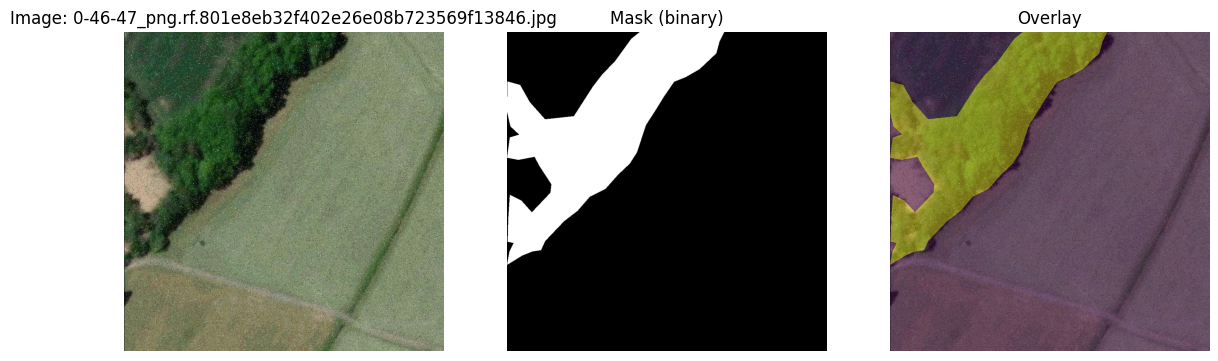

In [ ]:
# 1_visualize_random.py
import random
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/vegetation-segmentation-4')  # <- change if needed
SPLIT = 'train'  # 'train' / 'valid' / 'test'

def yolo_txt_to_mask(img_path, txt_path):
    img = Image.open(img_path).convert("RGB")
    w,h = img.size
    mask = Image.new("L", (w,h), 0)
    draw = ImageDraw.Draw(mask)
    text = txt_path.read_text().strip()
    if not text:
        return mask
    for line in text.splitlines():
        parts = line.strip().split()
        coords = list(map(float, parts[1:]))  # skip class id
        pts = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
        if pts:
            draw.polygon(pts, outline=1, fill=1)
    return mask

def load_mask_for_image(img_path, lbl_dir):
    base = img_path.stem
    # prefer image mask files
    for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']:
        p = lbl_dir/(base+ext)
        if p.exists():
            arr = np.array(Image.open(p))
            if arr.ndim==3:
                arr = arr[:,:,0]
            return (arr>0).astype(np.uint8)
    # fallback: YOLO .txt
    ptxt = lbl_dir/(base + '.txt')
    if ptxt.exists():
        return (np.array(yolo_txt_to_mask(img_path, ptxt))>0).astype(np.uint8)
    # missing label -> empty mask
    w,h = Image.open(img_path).size
    return np.zeros((h,w), dtype=np.uint8)

IMG_DIR = DATA_DIR/SPLIT/'images'
LBL_DIR = DATA_DIR/SPLIT/'labels'
imgs = sorted([p for p in IMG_DIR.iterdir() if p.is_file()])
if not imgs:
    raise SystemExit("No images found. Check DATA_DIR and folder structure.")

i = random.randrange(len(imgs))
img_path = imgs[i]
img = np.array(Image.open(img_path).convert('RGB'))
mask = load_mask_for_image(img_path, LBL_DIR)

plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(img); plt.title(f"Image: {img_path.name}"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Mask (binary)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(img); plt.imshow(mask, alpha=0.45); plt.title("Overlay"); plt.axis('off')
plt.show()


In [ ]:
# Convert YOLO-seg .txt -> binary mask PNGs for train/valid/test
# RUN in Colab. Adjust DATA_DIR if your folder is different.

from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np

DATA_DIR = Path('/content/vegetation-segmentation-4')  # change if needed
SPLITS = ['train', 'valid', 'test']
OVERWRITE = False   # set True to overwrite existing masks

def yolo_txt_to_mask(img_path: Path, txt_path: Path):
    """Return a PIL 'L' mask (0/255) from a YOLO-seg .txt file for the given image."""
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    text = txt_path.read_text().strip()
    if not text:
        return mask  # empty mask

    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) < 3:
            # not enough data to form a polygon
            continue
        # YOLO-seg commonly: <class> x1 y1 x2 y2 x3 y3 ...
        # skip first token (class id) and interpret remainder as normalized x,y pairs
        try:
            coords = list(map(float, parts[1:]))
        except:
            # if parsing fails, skip
            continue
        if len(coords) % 2 != 0:
            # odd count -- malformed polygon
            continue
        pts = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
        if len(pts) >= 3:
            # draw filled polygon as vegetation (white = 255)
            draw.polygon(pts, outline=255, fill=255)
    return mask

summary = {}

for split in SPLITS:
    img_dir = DATA_DIR/split/'images'
    lbl_dir = DATA_DIR/split/'labels'
    out_mask_dir = DATA_DIR/split/'masks'
    out_mask_dir.mkdir(parents=True, exist_ok=True)

    if not img_dir.exists():
        print(f"[WARN] images folder missing: {img_dir} (skipping {split})")
        summary[split] = {'images':0, 'txts':0, 'masks_created':0, 'skipped':0}
        continue
    if not lbl_dir.exists():
        print(f"[WARN] labels folder missing: {lbl_dir} (skipping {split})")
        summary[split] = {'images':0, 'txts':0, 'masks_created':0, 'skipped':0}
        continue

    images = sorted([p for p in img_dir.iterdir() if p.is_file()])
    txts = sorted([p for p in lbl_dir.glob('*.txt')])
    masks_created = 0
    skipped = 0
    missing_txt = 0

    for img_path in images:
        stem = img_path.stem
        txt_path = lbl_dir / (stem + '.txt')
        out_mask_path = out_mask_dir / (stem + '.png')

        if out_mask_path.exists() and not OVERWRITE:
            skipped += 1
            continue

        if txt_path.exists():
            mask_pil = yolo_txt_to_mask(img_path, txt_path)
            # convert to 0/255 uint8 and save
            mask_pil.save(out_mask_path, format='PNG')
            masks_created += 1
        else:
            # no txt annotation for this image -> create empty mask (optional)
            # If you prefer to not create files for missing labels, comment the two lines below.
            empty_mask = Image.new("L", Image.open(img_path).size, 0)
            empty_mask.save(out_mask_path, format='PNG')
            missing_txt += 1

    summary[split] = {
        'images': len(images),
        'txts': len(txts),
        'masks_created': masks_created,
        'skipped': skipped,
        'missing_txt_files': missing_txt
    }
    print(f"[{split}] images={len(images)}, .txt files={len(txts)}, masks_created={masks_created}, skipped(existing)={skipped}, missing_txt={missing_txt}")

print("\nConversion summary (per split):")
for s,v in summary.items():
    print(s, v)

print("\nDone. Masks saved to:")
for split in SPLITS:
    print("-", DATA_DIR/split/'masks')


[train] images=945, .txt files=945, masks_created=945, skipped(existing)=0, missing_txt=0
[valid] images=83, .txt files=83, masks_created=83, skipped(existing)=0, missing_txt=0
[test] images=40, .txt files=40, masks_created=40, skipped(existing)=0, missing_txt=0

Conversion summary (per split):
train {'images': 945, 'txts': 945, 'masks_created': 945, 'skipped': 0, 'missing_txt_files': 0}
valid {'images': 83, 'txts': 83, 'masks_created': 83, 'skipped': 0, 'missing_txt_files': 0}
test {'images': 40, 'txts': 40, 'masks_created': 40, 'skipped': 0, 'missing_txt_files': 0}

Done. Masks saved to:
- /content/vegetation-segmentation-4/train/masks
- /content/vegetation-segmentation-4/valid/masks
- /content/vegetation-segmentation-4/test/masks


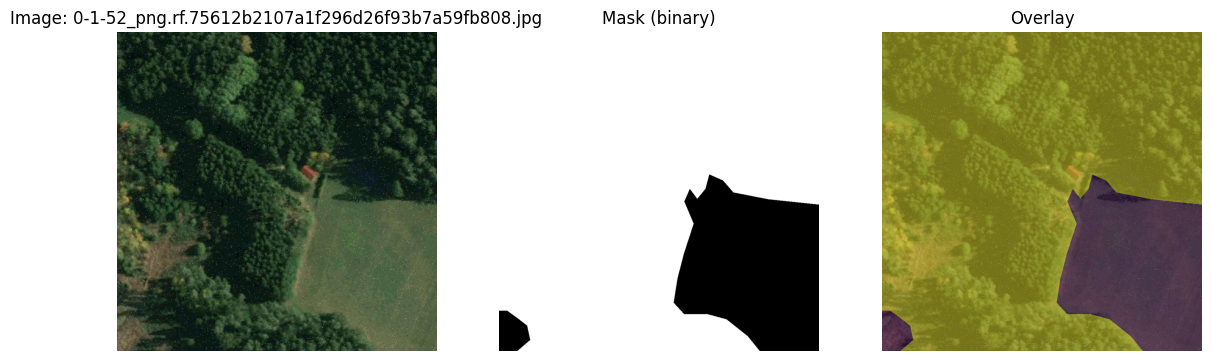

In [ ]:
# 1_visualize_random.py
import random
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/vegetation-segmentation-4')  # <- change if needed
SPLIT = 'train'  # 'train' / 'valid' / 'test'

def yolo_txt_to_mask(img_path, txt_path):
    img = Image.open(img_path).convert("RGB")
    w,h = img.size
    mask = Image.new("L", (w,h), 0)
    draw = ImageDraw.Draw(mask)
    text = txt_path.read_text().strip()
    if not text:
        return mask
    for line in text.splitlines():
        parts = line.strip().split()
        coords = list(map(float, parts[1:]))  # skip class id
        pts = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
        if pts:
            draw.polygon(pts, outline=1, fill=1)
    return mask

def load_mask_for_image(img_path, lbl_dir):
    base = img_path.stem
    # prefer image mask files
    for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']:
        p = lbl_dir/(base+ext)
        if p.exists():
            arr = np.array(Image.open(p))
            if arr.ndim==3:
                arr = arr[:,:,0]
            return (arr>0).astype(np.uint8)
    # fallback: YOLO .txt
    ptxt = lbl_dir/(base + '.txt')
    if ptxt.exists():
        return (np.array(yolo_txt_to_mask(img_path, ptxt))>0).astype(np.uint8)
    # missing label -> empty mask
    w,h = Image.open(img_path).size
    return np.zeros((h,w), dtype=np.uint8)

IMG_DIR = DATA_DIR/SPLIT/'images'
LBL_DIR = DATA_DIR/SPLIT/'labels'
imgs = sorted([p for p in IMG_DIR.iterdir() if p.is_file()])
if not imgs:
    raise SystemExit("No images found. Check DATA_DIR and folder structure.")

i = random.randrange(len(imgs))
img_path = imgs[i]
img = np.array(Image.open(img_path).convert('RGB'))
mask = load_mask_for_image(img_path, LBL_DIR)

plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(img); plt.title(f"Image: {img_path.name}"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Mask (binary)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(img); plt.imshow(mask, alpha=0.45); plt.title("Overlay"); plt.axis('off')
plt.show()


=== DATA CLEANLINESS REPORT ===


--- Checking TRAIN ---
✔ All images have masks
✔ All masks have images
✔ No corrupted files found
✔ All image-mask sizes match
✔ Masks contain only 0 and 255 values
⚠ Empty masks found: ['0-1-19_png.rf.02da791401b3e45bbd2d1fc8e32c96d8.png', '0-1-19_png.rf.4f998264178587902c3a10da8116cdd2.png', '0-1-19_png.rf.a14b70ab7c7e55a73e4511d869f67f62.png', '0-10-47_png.rf.6e64726bce9c25f762627a83871e78c7.png', '0-10-47_png.rf.98b3b4a89713c8e83b23ed3a95a30dc3.png', '0-10-47_png.rf.acd8d5a4237dcb53674db132b6970157.png', '0-13-58_png.rf.2531df3cf5ccf8837941d81d96d4eca5.png', '0-13-58_png.rf.265f41cd185db799e8694047989110a3.png', '0-13-58_png.rf.dd9d0b09d9b82762acb2e7f29d97d531.png', '0-13-5_png.rf.0f78a15fd3e819593a7d7477904f5006.png'] ... (showing first 10)

Showing sample overlay:


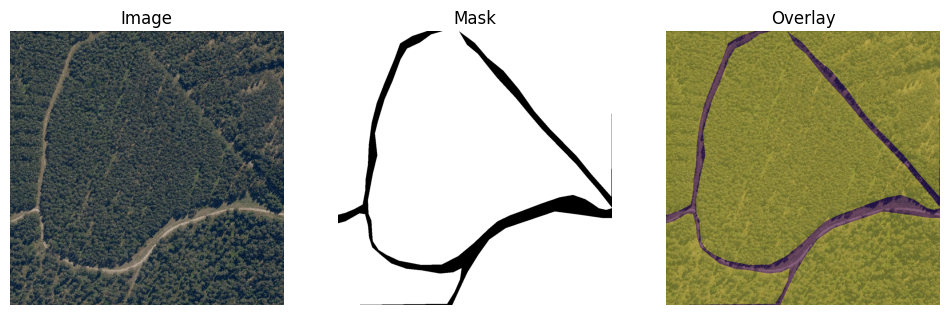


--- Checking VALID ---
✔ All images have masks
✔ All masks have images
✔ No corrupted files found
✔ All image-mask sizes match
✔ Masks contain only 0 and 255 values
⚠ Empty masks found: ['0-22-56_png.rf.8bf43a71796990d696d7ca5382d6a0bd.png', '0-25-27_png.rf.2e12b8648b4b795b1429435fa826309a.png', '0-4-45_png.rf.eb18e36d25649ee3e58a1c6ce83b591f.png', '0-42-49_png.rf.fc5444578c316c4f2c0a5de5d7ef238b.png', '0-43-31_png.rf.972b6b724526bde41727b82e0141777a.png', '0-56-47_png.rf.06449163ae892decb6b5ca9eaa3cca24.png', '0-65-25_png.rf.70e025f2068e6c4c00fbe0e52637a3f7.png', '0-69-26_png.rf.7a4091ba2fdb27b053f027c31f392522.png', '0-8-45_png.rf.4cc20587b08f5d7a0c5c93ee2e361328.png', '0-82-8_png.rf.2ff2845287fdbfa96011676314d81211.png'] ... (showing first 10)

Showing sample overlay:


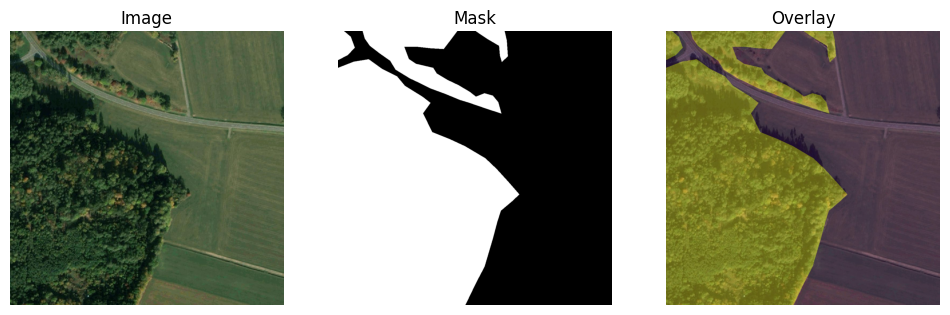


--- Checking TEST ---
✔ All images have masks
✔ All masks have images
✔ No corrupted files found
✔ All image-mask sizes match
✔ Masks contain only 0 and 255 values
⚠ Empty masks found: ['0-59-45_png.rf.be29100b779721b2adf81044c2a61a01.png', '0-70-25_png.rf.59d937be122cecdef46f845388b687ac.png', '0-80-59_png.rf.28d597dced79a7dc09fd4f93c909a506.png', '1-12-26_png.rf.759e05fc774593270341462170c0d534.png', '1-33-13_png.rf.45d6f3fa4b3cb6f7b42eaa83bdc520c0.png'] ... (showing first 10)

Showing sample overlay:


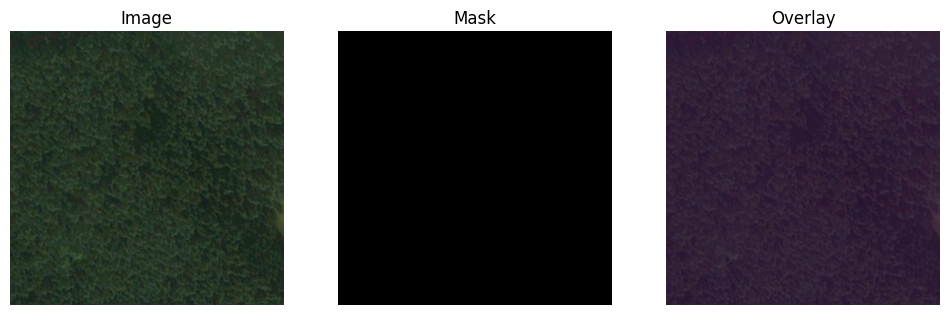


=== CLEANING CHECK COMPLETED ===


In [ ]:
# VERIFY_DATASET_CLEAN.py

from pathlib import Path
from PIL import Image
import numpy as np
import random
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/vegetation-segmentation-4')
SPLITS = ['train', 'valid', 'test']

def is_image_ok(path):
    try:
        Image.open(path).verify()
        return True
    except:
        return False

def visualize_sample(img_path, mask_path):
    img = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("L"))

    plt.figure(figsize=(12,5))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Mask"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(img); plt.imshow(mask, alpha=0.4); plt.title("Overlay"); plt.axis("off")
    plt.show()

print("=== DATA CLEANLINESS REPORT ===\n")

for split in SPLITS:
    img_dir = DATA_DIR/split/'images'
    mask_dir = DATA_DIR/split/'masks'

    img_paths = sorted([p for p in img_dir.iterdir() if p.is_file()])
    mask_paths = sorted([p for p in mask_dir.iterdir() if p.is_file()])

    print(f"\n--- Checking {split.upper()} ---")

    # 1. Pair checking
    img_stems = {p.stem for p in img_paths}
    mask_stems = {p.stem for p in mask_paths}
    missing_masks = img_stems - mask_stems
    missing_images = mask_stems - img_stems

    if missing_masks:
        print("❌ Missing masks:", missing_masks)
    else:
        print("✔ All images have masks")

    if missing_images:
        print("❌ Missing images:", missing_images)
    else:
        print("✔ All masks have images")

    # 2. Corrupted checks
    corrupted = []
    for p in img_paths + mask_paths:
        if not is_image_ok(p):
            corrupted.append(p.name)

    if corrupted:
        print("❌ Corrupted files:", corrupted)
    else:
        print("✔ No corrupted files found")

    # 3. Size match checks
    size_errors = []
    for img_p in img_paths:
        mask_p = mask_dir/(img_p.stem + ".png")
        if not mask_p.exists(): continue
        try:
            img = Image.open(img_p)
            mask = Image.open(mask_p)
            if img.size != mask.size:
                size_errors.append(img_p.stem)
        except:
            size_errors.append(img_p.stem)

    if size_errors:
        print("Size mismatch:", size_errors)
    else:
        print("✔ All image-mask sizes match")

    # 4. Check mask pixel values
    invalid_masks = []
    for m in mask_paths:
        mask = np.array(Image.open(m).convert("L"))
        unique_vals = set(np.unique(mask))
        # valid values: {0, 255}
        if not unique_vals.issubset({0, 255}):
            invalid_masks.append((m.name, unique_vals))

    if invalid_masks:
        print(" Masks with invalid pixel values:", invalid_masks)
    else:
        print("✔ Masks contain only 0 and 255 values")

    # 5. Check empty masks (optional)
    empty_masks = []
    for m in mask_paths:
        mask = np.array(Image.open(m).convert("L"))
        if mask.max() == 0:
            empty_masks.append(m.name)

    if empty_masks:
        print("⚠ Empty masks found:", empty_masks[:10], "... (showing first 10)")
    else:
        print("✔ No empty masks")

    # 6. Preview sample
    sample_img = random.choice(img_paths)
    sample_mask = mask_dir/(sample_img.stem + ".png")
    print("\nShowing sample overlay:")
    visualize_sample(sample_img, sample_mask)

print("\n=== CLEANING CHECK COMPLETED ===")


In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image

DATA_DIR = Path('/content/vegetation-segmentation-4')
SPLITS = ["train", "valid", "test"]

for split in SPLITS:
    mask_dir = DATA_DIR / split / "masks"

    empty_count = 0
    total = 0

    for m in mask_dir.iterdir():
        if m.is_file():
            total += 1
            mask = np.array(Image.open(m).convert("L"))
            if mask.max() == 0:
                empty_count += 1

    print(f"\n--- {split.upper()} ---")
    print("Total masks:", total)
    print("Empty masks:", empty_count)
    print("Percentage empty:", round((empty_count/total)*100, 2), "%")



--- TRAIN ---
Total masks: 945
Empty masks: 117
Percentage empty: 12.38 %

--- VALID ---
Total masks: 83
Empty masks: 10
Percentage empty: 12.05 %

--- TEST ---
Total masks: 40
Empty masks: 5
Percentage empty: 12.5 %


In [ ]:
import os
from pathlib import Path
from PIL import Image

DATA_DIR = Path('/content/vegetation-segmentation-4')  # change if needed

def count_files(split):
    img_dir = DATA_DIR/split/'images'
    lbl_dir = DATA_DIR/split/'labels'
    mask_dir = DATA_DIR/split/'masks'  # Roboflow sometimes includes this

    # Count images
    imgs = sorted([p for p in img_dir.iterdir() if p.is_file()])

    # Count YOLO segmentation labels (txt files)
    lbls = sorted([p for p in lbl_dir.iterdir() if p.is_file()])

    # Count masks only if masks/ exists
    if mask_dir.exists():
        masks = sorted([p for p in mask_dir.iterdir() if p.is_file()])
    else:
        masks = []

    return imgs, lbls, masks


# Totals
total_images = 0
total_labels = 0
total_masks = 0

print("==== Dataset Summary ====\n")
for split in ["train", "valid", "test"]:
    imgs, lbls, masks = count_files(split)

    print(f"{split.upper():5s} → images = {len(imgs):3d}, labels = {len(lbls):3d}, masks = {len(masks):3d}")

    total_images += len(imgs)
    total_labels += len(lbls)
    total_masks  += len(masks)

print("\n==============================")
print(f"TOTAL IMAGES IN DATASET = {total_images}")
print(f"TOTAL LABEL FILES       = {total_labels}")
print(f"TOTAL MASK FILES        = {total_masks}")
print("==============================\n")


# Display data.yaml if present
yaml_path = DATA_DIR / 'data.yaml'
if yaml_path.exists():
    print("--- data.yaml ---")
    print(yaml_path.read_text())
else:
    print("No data.yaml found at", yaml_path)


==== Dataset Summary ====

TRAIN → images = 945, labels = 945, masks = 945
VALID → images =  83, labels =  83, masks =  83
TEST  → images =  40, labels =  40, masks =  40

TOTAL IMAGES IN DATASET = 1068
TOTAL LABEL FILES       = 1068
TOTAL MASK FILES        = 1068

--- data.yaml ---
names:
- vegetation
nc: 1
roboflow:
  license: Public Domain
  project: vegetation-segmentation
  url: https://universe.roboflow.com/blue-halo/vegetation-segmentation/dataset/4
  version: 4
  workspace: blue-halo
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
from pathlib import Path

from PIL import Image
import numpy as np

ROOT = Path('/content/vegetation-segmentation-4')
for split in ['train','valid','test']:
    md = ROOT/split/'masks'
    if not md.exists(): continue
    for p in md.iterdir():
        if not p.is_file(): continue
        m = Image.open(p).convert('L')
        arr = np.array(m)
        # threshold - anything >0 becomes 255
        arr = (arr > 127).astype('uint8') * 255
        Image.fromarray(arr, mode='L').save(p)
print("Normalized all masks to 0/255, mode 'L'.")


'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)


Normalized all masks to 0/255, mode 'L'.


In [ ]:
# Step 1: Check TF & GPU
import tensorflow as tf, sys
print("Python:", sys.version.splitlines()[0])
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os, random, math
from pathlib import Path
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import matplotlib.pyplot as plt

In [ ]:
# ------------------ CONFIG (edit if needed) ------------------
DATA_ROOT = Path('/content/vegetation-segmentation-4')   # <- point to folder shown in your screenshot
BACKBONE = 'mobilenetv2'    # 'mobilenetv2' (light) or 'resnet50' (stronger)
IMG_SIZE = (256, 256)       # (width, height). Use 384/512 if you have a GPU with memory.
BATCH_SIZE = 8              # reduce if OOM
EPOCHS = 40
CHECKPOINT_DIR = Path('/content/deeplab_checkpoints'); CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PRED_OUT = Path('/content/deeplab_predictions'); PRED_OUT.mkdir(parents=True, exist_ok=True)
SEED = 42
AUTO = tf.data.AUTOTUNE
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
# ------------------------------------------------------------

In [ ]:
# ---------- quick dataset sanity & listing ----------
def list_split(split):
    img_dir = DATA_ROOT/split/'images'
    mask_dir = DATA_ROOT/split/'masks'
    imgs = sorted([str(p) for p in img_dir.glob('*')]) if img_dir.exists() else []
    masks = []
    for p in imgs:
        stem = Path(p).stem
        m = mask_dir/(stem + '.png')
        # try other mask extensions
        if not m.exists():
            for ext in ['.jpg','.jpeg','.bmp','.tiff']:
                cand = mask_dir/(stem+ext)
                if cand.exists():
                    m = cand
                    break
        masks.append(str(m) if m.exists() else '')
    return imgs, masks

train_imgs, train_masks = list_split('train')
valid_imgs, valid_masks = list_split('valid')
test_imgs, test_masks   = list_split('test')

print("DATA ROOT:", DATA_ROOT)
print("Counts -> train, valid, test:", len(train_imgs), len(valid_imgs), len(test_imgs))

if len(train_imgs)==0 and len(valid_imgs)==0 and len(test_imgs)==0:
    raise SystemExit("No images found. Check DATA_ROOT and folder structure.")


DATA ROOT: /content/vegetation-segmentation-4
Counts -> train, valid, test: 945 83 40


In [ ]:
import tensorflow as tf
from keras.saving import register_keras_serializable

@register_keras_serializable()
def resize_pool(inputs):
    p, feat = inputs
    target_size = tf.shape(feat)[1:3]
    return tf.image.resize(p, target_size, method='bilinear')

@register_keras_serializable()
def out_shape(input_shapes):
    feat_shape = input_shapes[1]
    if feat_shape[1] is None or feat_shape[2] is None:
        return (None, None, None, 256)
    return (feat_shape[0], feat_shape[1], feat_shape[2], 256)


In [ ]:
model = tf.keras.models.load_model(
    "/content/deeplab_checkpoints/best_deeplab_mobilenetv2.h5",
    custom_objects={
        "resize_pool": resize_pool,
        "out_shape": out_shape
    },
    compile=False
)


In [ ]:
model.save("/content/vegetation_saved_model", save_format="tf")


ValueError: The `save_format` argument is deprecated in Keras 3. Please remove this argument and pass a file path with either `.keras` or `.h5` extension.Received: save_format=tf

In [ ]:
# ---------- tf.data loader ----------
def _read_image_mask(img_path, mask_path):
    # img_path, mask_path are tf.string
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')

    mask_path = tf.strings.strip(mask_path)
    def read_mask(p):
        m = tf.io.read_file(p)
        m = tf.image.decode_image(m, channels=1, expand_animations=False)
        # threshold so mask becomes 0/1
        m = tf.cast(m > 127, tf.float32)
        m = tf.image.resize(m, IMG_SIZE, method='nearest')
        return m

    mask = tf.cond(tf.equal(tf.strings.length(mask_path), 0),
                   lambda: tf.zeros([IMG_SIZE[1], IMG_SIZE[0], 1], tf.float32),
                   lambda: read_mask(mask_path))
    return img, mask

def build_dataset(img_list, mask_list, training=True):
    ds = tf.data.Dataset.from_tensor_slices((img_list, mask_list))
    if training:
        ds = ds.shuffle(buffer_size=max(1000, len(img_list)), seed=SEED)
    ds = ds.map(lambda i,m: _read_image_mask(i,m), num_parallel_calls=AUTO)
    if training:
        def augment(img, mask):
            if tf.random.uniform([]) < 0.5:
                img = tf.image.flip_left_right(img); mask = tf.image.flip_left_right(mask)
            if tf.random.uniform([]) < 0.25:
                img = tf.image.flip_up_down(img); mask = tf.image.flip_up_down(mask)
            k = tf.random.uniform([], 0, 4, dtype=tf.int32)
            img = tf.image.rot90(img, k); mask = tf.image.rot90(mask, k)
            img = tf.image.random_brightness(img, 0.06)
            img = tf.image.random_contrast(img, 0.9, 1.1)
            return img, mask
        ds = ds.map(augment, num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTO)
    return ds

train_ds = build_dataset(train_imgs, train_masks, training=True)
valid_ds = build_dataset(valid_imgs, valid_masks, training=False)
test_ds  = build_dataset(test_imgs, test_masks, training=False)

In [ ]:
# --- Corrected ASPP + DeepLabV3+ builder (Keras-safe) ---
from tensorflow.keras import layers, models
import tensorflow as tf

def SepConv_BN(x, filters, kernel, rate=1, name=None):
    x = layers.SeparableConv2D(filters, kernel, padding='same', dilation_rate=rate,
                               use_bias=False, name=None if name is None else name + '_sepconv')(x)
    x = layers.BatchNormalization(name=None if name is None else name + '_bn')(x)
    x = layers.Activation('relu')(x)
    return x

def ASPP(x, depth=256):
    # pooled branch (global average -> conv -> resize to match x spatial dims)
    pool = layers.GlobalAveragePooling2D()(x)                 # (batch, channels)
    pool = layers.Reshape((1,1,int(pool.shape[-1])))(pool)    # (batch,1,1,channels)
    pool = layers.Conv2D(depth, 1, padding='same', use_bias=False)(pool)
    pool = layers.BatchNormalization()(pool)
    pool = layers.Activation('relu')(pool)

    # Resize pooled -> must know spatial size of `x`. Pass both tensors into Lambda.
    def resize_pool(inputs):
        p, feat = inputs  # p: pooled (b,1,1,c), feat: feature map (b,H,W,C)
        target_size = tf.shape(feat)[1:3]
        return tf.image.resize(p, target_size, method='bilinear')

    def out_shape(input_shapes):
        # input_shapes is a tuple: (pool_shape, feat_shape)
        # pool_shape = (None,1,1,channels); feat_shape = (None,H,W,C)
        # We want output shape: (None, H, W, depth)
        feat_shape = input_shapes[1]
        if feat_shape[1] is None or feat_shape[2] is None:
            return (None, None, None, depth)
        return (feat_shape[0], feat_shape[1], feat_shape[2], depth)

    pool = layers.Lambda(resize_pool, output_shape=out_shape)([pool, x])

    # 1x1 conv branch
    conv_1x1 = layers.Conv2D(depth, 1, padding='same', use_bias=False)(x)
    conv_1x1 = layers.BatchNormalization()(conv_1x1)
    conv_1x1 = layers.Activation('relu')(conv_1x1)

    # atrous separable conv branches
    atrous_1 = SepConv_BN(x, depth, 3, rate=6)
    atrous_2 = SepConv_BN(x, depth, 3, rate=12)
    atrous_3 = SepConv_BN(x, depth, 3, rate=18)

    # concat & projection
    x = layers.Concatenate()([pool, conv_1x1, atrous_1, atrous_2, atrous_3])
    x = layers.Conv2D(depth, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def DeepLabV3Plus(input_shape=(256,256,3), backbone='mobilenetv2'):
    inputs = layers.Input(shape=input_shape)

    if backbone == 'mobilenetv2':
        base = tf.keras.applications.MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet')
        low_level = base.get_layer('block_3_expand_relu').output   # ~1/4 resolution
        x = base.get_layer('block_13_expand_relu').output          # ~1/16 resolution
    elif backbone == 'resnet50':
        base = tf.keras.applications.ResNet50(input_tensor=inputs, include_top=False, weights='imagenet')
        low_level = base.get_layer('conv2_block3_out').output
        x = base.get_layer('conv4_block6_out').output
    else:
        raise ValueError("Backbone must be 'mobilenetv2' or 'resnet50'")

    # ASPP
    x = ASPP(x, depth=256)

    # Upsample ASPP output to 1/4 (assuming backbone produces 1/16 feature)
    x = layers.UpSampling2D(size=(4,4), interpolation='bilinear')(x)

    # process low-level features
    low_level_proc = layers.Conv2D(48, 1, padding='same', use_bias=False)(low_level)
    low_level_proc = layers.BatchNormalization()(low_level_proc)
    low_level_proc = layers.Activation('relu')(low_level_proc)

    x = layers.Concatenate()([x, low_level_proc])
    x = SepConv_BN(x, 256, 3)
    x = SepConv_BN(x, 256, 3)

    # final upsample to input resolution
    x = layers.UpSampling2D(size=(4,4), interpolation='bilinear')(x)
    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name=f"DeepLabV3Plus_{backbone}")
    return model


In [ ]:
model = DeepLabV3Plus(input_shape=(*IMG_SIZE,3), backbone=BACKBONE)
model.summary()


`input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "DeepLabV3Plus_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,451,569 (9.35 MB)

 Trainable params: 2,429,585 (9.27 MB)

 Non-trainable params: 21,984 (85.88 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

# -------------------------
# Dice Loss
# -------------------------
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# -------------------------
# BCE + Dice Loss
# -------------------------
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return bce + d_loss

# -------------------------
# Dice Metric
# -------------------------
class DiceMetric(tf.keras.metrics.Metric):
    def __init__(self, name='dice', **kwargs):
        super().__init__(name=name, **kwargs)
        self.dice_score = self.add_weight(name="ds", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.round(y_pred)
        intersection = tf.reduce_sum(y_true * y_pred)
        union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
        dice = (2. * intersection + 1e-6) / (union + 1e-6)
        self.dice_score.assign(dice)

    def result(self):
        return self.dice_score

    def reset_states(self):
        self.dice_score.assign(0.0)

# -------------------------
# IoU Metric
# -------------------------
class IoUMetric(tf.keras.metrics.Metric):
    def __init__(self, name='iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.iou_score = self.add_weight(name="iou", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.round(y_pred)
        intersection = tf.reduce_sum(y_true * y_pred)
        union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)
        self.iou_score.assign(iou)

    def result(self):
        return self.iou_score

    def reset_states(self):
        self.iou_score.assign(0.0)


In [ ]:
model.compile(optimizer=optimizers.Adam(1e-4),
              loss=bce_dice_loss,
              metrics=[DiceMetric(), IoUMetric(), 'binary_accuracy'])


In [ ]:
import tensorflow as tf

CKPT_DIR = "/content/deeplab_checkpoints"
CKPT_FILE = CKPT_DIR + "/best_deeplab_mobilenetv2.h5"

cbs = [
    tf.keras.callbacks.ModelCheckpoint(
        CKPT_FILE,
        save_best_only=True,
        monitor='val_loss',
        mode='min'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]


In [ ]:
history = model.fit(train_ds, validation_data=valid_ds, epochs=20, callbacks=cbs)


Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - binary_accuracy: 0.7865 - dice: 0.8144 - iou: 0.7132 - loss: 0.8449

119/119 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - binary_accuracy: 0.7870 - dice: 0.8143 - iou: 0.7128 - loss: 0.8428 - val_binary_accuracy: 0.7555 - val_dice: 0.6339 - val_iou: 0.4640 - val_loss: 1.2138 - learning_rate: 1.0000e-04
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - binary_accuracy: 0.8889 - dice: 0.8846 - iou: 0.8022 - loss: 0.4488

119/119 ━━━━━━━━━━━━━━━━━━━━ 55s 458ms/step - binary_accuracy: 0.8890 - dice: 0.8831 - iou: 0.8001 - loss: 0.4486 - val_binary_accuracy: 0.8769 - val_dice: 0.3635 - val_iou: 0.2222 - val_loss: 1.1694 - learning_rate: 1.0000e-04
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 56s 464ms/step - binary_accuracy: 0.9143 - dice: 0.9064 - iou: 0.8328 - loss: 0.3400 - val_binary_accuracy: 0.5619 - val_dice: 0.0185 - val_iou: 0.0093 - val_loss: 1.1894 - learning_rate: 1.0000e-04
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 477ms/step - binary_accuracy: 0.9301 - dice: 0.9164 - iou: 0.8512 - loss: 0.2932 - val_binary_accuracy: 0.6327 - val_dice: 0.0196 - val_iou: 0.0099 - val_loss: 1.3853 - learning_rate: 1.0000e-04
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - binary_accuracy: 0.9318 - dice: 0.9233 - iou: 0.8606 - loss: 0.2795
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 477ms/step - binary_accuracy: 0.9318 - dice: 0.9215 - iou: 0.

119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 491ms/step - binary_accuracy: 0.9444 - dice: 0.9375 - iou: 0.8846 - loss: 0.2332 - val_binary_accuracy: 0.7501 - val_dice: 0.3815 - val_iou: 0.2357 - val_loss: 1.1657 - learning_rate: 2.5000e-05
Epoch 11/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - binary_accuracy: 0.9469 - dice: 0.9388 - iou: 0.8873 - loss: 0.2265

119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 498ms/step - binary_accuracy: 0.9469 - dice: 0.9390 - iou: 0.8876 - loss: 0.2265 - val_binary_accuracy: 0.7877 - val_dice: 0.2696 - val_iou: 0.1558 - val_loss: 0.9745 - learning_rate: 2.5000e-05
Epoch 12/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - binary_accuracy: 0.9486 - dice: 0.9389 - iou: 0.8887 - loss: 0.2174

...

119/119 ━━━━━━━━━━━━━━━━━━━━ 58s 489ms/step - binary_accuracy: 0.9513 - dice: 0.9279 - iou: 0.8795 - loss: 0.2033 - val_binary_accuracy: 0.8242 - val_dice: 0.4616 - val_iou: 0.3000 - val_loss: 0.8843 - learning_rate: 2.5000e-05
Epoch 14/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - binary_accuracy: 0.9470 - dice: 0.9331 - iou: 0.8833 - loss: 0.2270

119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 496ms/step - binary_accuracy: 0.9470 - dice: 0.9253 - iou: 0.8759 - loss: 0.2270 - val_binary_accuracy: 0.8871 - val_dice: 0.6401 - val_iou: 0.4707 - val_loss: 0.5593 - learning_rate: 2.5000e-05
Epoch 15/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - binary_accuracy: 0.9508 - dice: 0.9444 - iou: 0.8961 - loss: 0.2055

119/119 ━━━━━━━━━━━━━━━━━━━━ 58s 488ms/step - binary_accuracy: 0.9508 - dice: 0.9438 - iou: 0.8951 - loss: 0.2055 - val_binary_accuracy: 0.8830 - val_dice: 0.7387 - val_iou: 0.5857 - val_loss: 0.5363 - learning_rate: 2.5000e-05
Epoch 16/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 58s 484ms/step - binary_accuracy: 0.9477 - dice: 0.9316 - iou: 0.8807 - loss: 0.2287 - val_binary_accuracy: 0.8551 - val_dice: 0.7248 - val_iou: 0.5684 - val_loss: 0.7105 - learning_rate: 2.5000e-05
Epoch 17/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - binary_accuracy: 0.9511 - dice: 0.9416 - iou: 0.8925 - loss: 0.2082

119/119 ━━━━━━━━━━━━━━━━━━━━ 81s 478ms/step - binary_accuracy: 0.9511 - dice: 0.9383 - iou: 0.8881 - loss: 0.2082 - val_binary_accuracy: 0.9115 - val_dice: 0.7482 - val_iou: 0.5976 - val_loss: 0.4476 - learning_rate: 2.5000e-05
Epoch 18/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - binary_accuracy: 0.9487 - dice: 0.9439 - iou: 0.8956 - loss: 0.2070

119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 478ms/step - binary_accuracy: 0.9487 - dice: 0.9419 - iou: 0.8926 - loss: 0.2069 - val_binary_accuracy: 0.9171 - val_dice: 0.7876 - val_iou: 0.6496 - val_loss: 0.3856 - learning_rate: 2.5000e-05
Epoch 19/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 473ms/step - binary_accuracy: 0.9519 - dice: 0.9300 - iou: 0.8844 - loss: 0.2051 - val_binary_accuracy: 0.9041 - val_dice: 0.7952 - val_iou: 0.6600 - val_loss: 0.4361 - learning_rate: 2.5000e-05
Epoch 20/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 479ms/step - binary_accuracy: 0.9527 - dice: 0.9410 - iou: 0.8933 - loss: 0.1987 - val_binary_accuracy: 0.9122 - val_dice: 0.8138 - val_iou: 0.6860 - val_loss: 0.3960 - learning_rate: 2.5000e-05


In [ ]:
import sys
print(sys.version)


In [ ]:
!find /content -name "*.h5"


/content/deeplab_checkpoints/best_deeplab_mobilenetv2.h5


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/deeplab_checkpoints/best_deeplab_mobilenetv2.h5",
    compile=False
)

print("Model loaded successfully")


Model loaded successfully


In [ ]:
model.export("/content/vegetation_saved_model")
print("SavedModel exported successfully")


Saved artifact at '/content/vegetation_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')]
Output Type:
  TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)
Captures:
  139669946938384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946938192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946937040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946938000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946939152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946937424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946937616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946938960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946938576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139669946940112: TensorSpec(shape=(), dtype=tf.resourc

In [ ]:
import shutil
shutil.make_archive(
    "vegetation_saved_model",
    "zip",
    "/content/vegetation_saved_model"
)


'/content/vegetation_saved_model.zip'

In [ ]:
from google.colab import files
files.download("vegetation_saved_model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# -------- PREPROCESS IMAGE --------
def preprocess_image(img_path, size=IMG_SIZE):
    img = Image.open(img_path).convert('RGB')
    img = img.resize(size, Image.BILINEAR)
    arr = np.array(img).astype('float32') / 255.0
    return img, arr

# -------- PREDICT MASK --------
def predict_mask(model, img_path, size=IMG_SIZE, thr=0.5):
    img_orig, arr = preprocess_image(img_path, size=size)
    pred = model.predict(np.expand_dims(arr, axis=0))[0]
    prob = pred[:,:,0]                       # probability mask
    binary = (prob > thr).astype(np.uint8)   # threshold → binary mask
    return img_orig, prob, binary


In [ ]:
# ---------- helpers for percent output ----------
import numpy as np
from PIL import Image
import tensorflow as tf

IMG_SIZE = (256, 256)   # model input size

def preprocess_for_model(img_pil, size=IMG_SIZE):
    img_resized = img_pil.convert('RGB').resize(size, Image.BILINEAR)
    arr = np.array(img_resized).astype('float32') / 255.0
    return arr

def compute_vegetation_percentage(model, img_path_or_pil, prob_thr=0.5, size=IMG_SIZE, return_masks=True):

    # load image
    if isinstance(img_path_or_pil, str):
        img = Image.open(img_path_or_pil).convert('RGB')
    else:
        img = img_path_or_pil.convert('RGB')

    orig_w, orig_h = img.size

    arr = preprocess_for_model(img, size=size)
    prob = model.predict(np.expand_dims(arr, 0))[0,:,:,0]
    bin_mask = (prob > prob_thr).astype(np.uint8) * 255

    mask_orig = Image.fromarray(bin_mask).resize((orig_w, orig_h), Image.NEAREST)
    mask_arr = np.array(mask_orig)

    veg_pixels = (mask_arr > 127).sum()
    total_pixels = orig_w * orig_h
    veg_pct = (veg_pixels / total_pixels) * 100
    nonveg_pct = 100 - veg_pct

    # probability map resized for visualization
    prob_map = Image.fromarray((prob * 255).astype('uint8')).resize((orig_w, orig_h), Image.BILINEAR)
    prob_map = np.array(prob_map).astype('float32') / 255.0

    return veg_pct, nonveg_pct, prob_map, mask_arr


Saving Screenshot 2025-11-29 020322.png to Screenshot 2025-11-29 020322.png
Uploaded file: Screenshot 2025-11-29 020322.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

===== RESULTS =====
Vegetation Percentage: 59.11%
Non-Vegetation Percentage: 40.89%


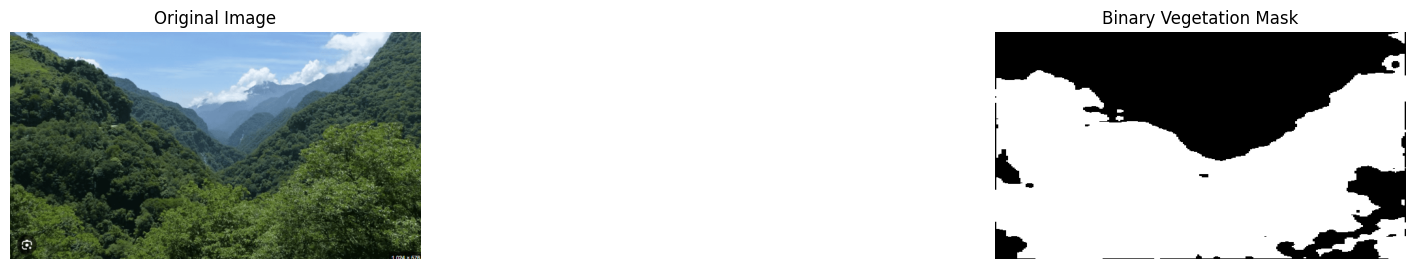

In [ ]:
# ================================
# UPLOAD → PREDICT → VISUALIZE
# ================================

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# ----------- Upload Image -----------
uploaded = files.upload()

img_path = list(uploaded.keys())[0]   # first uploaded file
print("Uploaded file:", img_path)


# ----------- Run Prediction -----------
veg_pct, nonveg_pct, prob_map, bin_mask = compute_vegetation_percentage(
    model,           # your trained model
    img_path,        # uploaded image
    prob_thr=0.5,
    return_masks=True
)

print("\n===== RESULTS =====")
print(f"Vegetation Percentage: {veg_pct:.2f}%")
print(f"Non-Vegetation Percentage: {nonveg_pct:.2f}%")


# ----------- Visualization -----------
orig = Image.open(img_path)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(orig)
plt.axis("off")
plt.subplot(1,3,3)
plt.title("Binary Vegetation Mask")
plt.imshow(bin_mask, cmap="gray")
plt.axis("off")

plt.show()
